<h1>Chapter 8-Homework-Problem 2</h1>

<p>Inflation remains an important macroeconomic concern in the United States. In this exercise, we will use a neural network to model and forecast inflation dynamics. Using monthly data from FRED, construct a time series of the U.S. inflation rate (e.g., based on the Consumer Price Index).</p>

<p>This task requires the following:</p>

<p>•	Build a feedforward neural network or LSTM model to forecast inflation.<br />
•	Use the model to generate out-of-sample forecasts for the last two years of the dataset.<br />
•	Ensure that these forecasts are truly out-of-sample, i.e., not used in training.<br />
•	Plot the actual vs. predicted inflation rates over the forecast period. Please comment on the forecast.</p>


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.8652 - val_loss: 9.0063
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.9216 - val_loss: 5.2205
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5961 - val_loss: 3.5913
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8686 - val_loss: 4.0305
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5032 - val_loss: 4.1148
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2689 - val_loss: 4.0612
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0706 - val_loss: 3.8372
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9273 - val_loss: 3.7754
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
RMSE: 1.5786
MAE:  1.1954


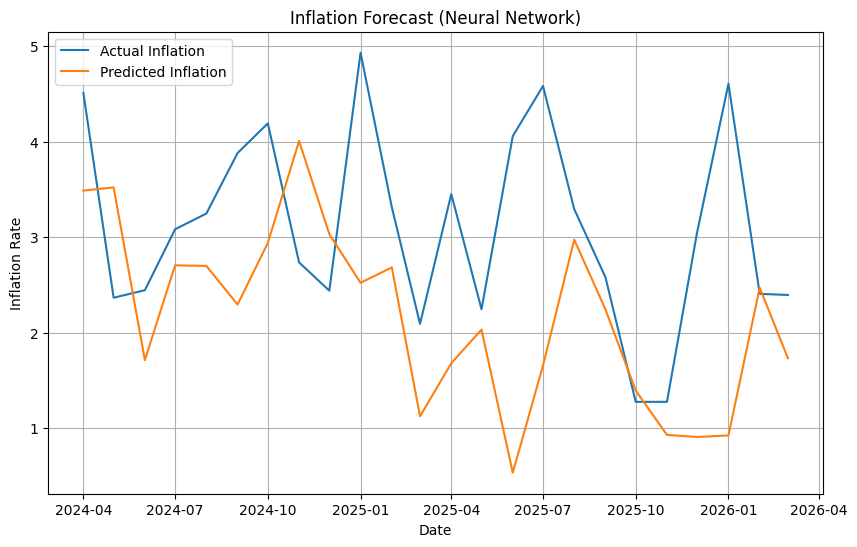

In [1]:
# ================================
# 1. Import libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ================================
# 2. Load data
# ================================
df = pd.read_csv("Chapter_08-inflation.csv")

# Convert date
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# ================================
# 3. Create lagged features
# ================================
def create_lags(data, lags=12):
    df_lag = data.copy()
    for i in range(1, lags+1):
        df_lag[f"lag_{i}"] = df_lag["Inflation"].shift(i)
    return df_lag

df_lag = create_lags(df, lags=12)

# Drop missing values from lags
df_lag = df_lag.dropna()

# ================================
# 4. Train-test split (last 2 years = test)
# ================================
# 24 months test set
train = df_lag.iloc[:-24]
test = df_lag.iloc[-24:]

X_train = train.drop(["Date", "Inflation"], axis=1)
y_train = train["Inflation"]

X_test = test.drop(["Date", "Inflation"], axis=1)
y_test = test["Inflation"]

# ================================
# 5. Scale features
# ================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================
# 6. Build neural network
# ================================
model = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

# Compile
model.compile(
    optimizer='adam',
    loss='mse'
)

# Early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ================================
# 7. Train model
# ================================
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ================================
# 8. Forecast (out-of-sample)
# ================================
y_pred = model.predict(X_test_scaled).flatten()

# ================================
# 9. Evaluation
# ================================
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

# ================================
# 10. Plot results
# ================================
plt.figure(figsize=(10,6))

plt.plot(test["Date"], y_test, label="Actual Inflation")
plt.plot(test["Date"], y_pred, label="Predicted Inflation")

plt.title("Inflation Forecast (Neural Network)")
plt.xlabel("Date")
plt.ylabel("Inflation Rate")
plt.legend()
plt.grid()

plt.show()
